## Mécanique du vol, 2023-2024
#### Université Paul Sabatier, ENSEEIHT

Auteur: Christophe.Airiau@imft.fr

<table style="width: 100%">
    <colgroup>
       <col span="1" style="width: 40%;">
       <col span="1" style="width: 20%;">
       <col span="1" style="width: 45%;">
    </colgroup>
    <tbody>
        <tr>
            <td style="background-color: #ffffff"><img src="Images/fsi.png" width="200"></td>
            <td style="background-color: #ffffff"> </td>
            <td style="background-color: #ffffff"><img src="Images/N7.png" width="200"></td>
        </tr>
    </tbody>
</table>
 
 



# **<span style="color:orange">Polaire décalée</span>**



# Introduction

 
 
# **<span style="color:red">Objectifs</span>**

1. Déterminer les caractéristiques avions et aérodynamiques pour une configuration en finesse maximale 
2. Déterminer les caractéristiques avions et aérodynamiques pour une configuration de puissance requise minimale
3. Utiliser un module Python pour résoudre un problème d'ingénierie 
 


<hr style="border:2px solid orange " width="99%">

# **<span style="color:red">Définition de la polaire décalée</span>**
 
<hr style="border:2px solid orange " width="99%">
 
<div class="alert alert-block alert-danger">
<b> Polaire décalée </b>
$$
C_D = C_{D_0} + k~(C_L-C_{L_0})^2,  \qquad \qquad k = \dfrac{1}{\pi~\lambda~e}
$$
</div>
 
 
<div class="alert alert-block alert-info">
<b> Formulation polynomiale de la polaire décalée </b>
$$
C_D = a_0 + a_1 C_L + a_2 C_L^2
$$
</div>
Il est aisé de trouver les relations entre les coefficients pour les deux formulations.

<hr style="border:2px solid orange " width="99%">

# **<span style="color:red">I - Finesse optimale</span>**

<hr style="border:2px solid orange " width="99%">

### Méthode

La finesse optimale correspond à la **maximisation** de :
<div class="alert alert-block alert-danger">
<b> Polaire décalée </b>
$$
f_{\max} = \max_{C_L}~\dfrac{C_L}{C_{D_0} + k~(C_L-C_{L_0})^2}
$$
</div>


C'est plus simple pratiquement de **minimiser** son inverse:
$$
\dfrac 1  f =  \dfrac{C_{D_0} + k~(C_L-C_{L_0})^2} {C_L} 
$$

1. On dérive par rapport à $C_L$

2. On trouve le $C_{L_3}$ , $C_{D_3}$ et la $f_{\max}$.

3. Avec l'équation de la portance on trouve la vitesse optimale:

<div class="alert alert-block alert-info">
<b>Calcul de la vitesse </b>
    
$$
W = \dfrac 1 2~\rho~V_3^2~S~C_{L_3}
$$ 
    
</div>
    
3. On trouve aussi la puissance requise : 
    
<div class="alert alert-block alert-info">
<b>Calcul de la puissance requise </b>
    
$$
Pr_3 = D_3 \times V_3 = \dfrac 1 2~\rho~S~C_{D_3}~V_3^3
$$    
</div
    

**l'indice 3 correspond à l'index de ce cas: polaire décalée + finesse optimale**

Pour rappel on avait l'indice 1 pour la polaire centrée + finesse optimale.

 ###  **<span style="color:magenta"> Calcul de la finesse optimale, des $C_L$, $C_D$ et $D$ et de la puissance $P_r$ correspondant </span>**

In [4]:
# imports and local module 
from sympy.interactive import init_printing
import sympy.printing as printing
# %matplotlib notebook
from sympy import Symbol, symbols, simplify, expand, integrate, diff, solveset, Abs, diff, collect, solve, pi
from sympy import latex, lambdify, sqrt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from IPython.display import display, Latex
style_list = mpl.style.available
print("Plot styles: ", style_list)
plt.style.use(style_list[11])  # choisir son style ...
init_printing()

Plot styles:  ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [5]:
def print_(var, value):
    result = "$${} \qquad : \qquad {}$$".format(var, latex(value))
    display(Latex(result))

# déclaration des variables
C_D0, C_L, k, C_L0 = symbols("C_D0, C_L, k, C_L0")
q, S, rho, V, rho_0 = symbols("q, S, rho, V, rho_0")
lambda_, e, f = symbols("lambda_, e, f")
k_value = symbols("k_value")
W, m, g, sigma, epsilon = symbols("W, m , g, sigma, epsilon")
k_value = 1 / (pi * lambda_ * e)
C_L0 = epsilon * sqrt(C_D0/k)

###  Calcul de $C_L$


* Calcul de $\dfrac{df}{dC_L}$ puis le $C_L$ optimal $C_{L_3}$

* Prendre la solution **positive**

In [6]:
C_D = C_D0 + k * (C_L - C_L0)**2
f = C_L / C_D
inv_f = 1 / f
d_invf = simplify(inv_f.diff(C_L))
sol = solve(d_invf, C_L)
print_("Solution", sol)

<IPython.core.display.Latex object>

On exprime le $C_{L_3}$ en fonction de $\lambda$ et $e$

In [7]:
C_L_3 = sol[1]
# je change la formule pour une meilleure écriture et plus de simplification plus loin
C_L_3 = sqrt(1 + epsilon**2) * sqrt(C_D0 / k)
print_("C_{L_3}", C_L_3)
C_L_3.subs(k, k_value)

<IPython.core.display.Latex object>

### Résultats

On peut facilement montrer que 

 <div class="alert alert-block alert-success">
<b>  </b>
 $$C_{L_3}^2   =   C_{L_0}^2+\dfrac{C_{D_0}}{k}$$
</div>

Ajoutons **quelques notations**:

* On appelle le $C_{L_{ref}}$ la valeur optimal trouvée pour la polaire classique 

<div class="alert alert-block alert-info">
<b> Valeur de $C_{L_{ref}}$ </b>
$$C_{L_{ref}}^2 = \dfrac{C_{D_0}}{k}$$ 
</div>

* On introduit un paramètre de correction $\epsilon$ tel que

<div class="alert alert-block alert-info">
<b> Valeur de $\epsilon$ </b>
$$\epsilon^2 = \left(\dfrac{C_{L_0}}{C_{L_{ref}}}\right)^2 = \dfrac{k~C_{L_0}^2}{C_{D_0}}$$  
</div>


* On montre alors 

<div class="alert alert-block alert-success">
<b>  </b>
$$C_{L_3}^2   = C_{L_{ref}}^2~(1 +\epsilon^2)$$
</div>


On trouve ici une correction du coefficient de portance optimal par rapport à celui classique.

Avec ces notations on peut écrire une polaire sous la forme de rapports:

<div class="alert alert-block alert-danger">
<b> Polaire décalée </b>
$$
\dfrac{C_D}{C_{D_0}}  = 1 +  \left(\dfrac{C_L}{C_{L_{ref}}}- \epsilon\right)^2
$$
</div>

Cette dernière relation est employée plus loin.
 

### Calcul du $C_D$ optimal, de la finesse maximale et de la traînée correspondante

In [8]:
C_D_3 = C_D.subs(C_L, C_L_3)
f_max = f.subs(C_L, C_L_3)
print_("C_{D_3}", C_D_3)
print_("C_{D_3}", C_D_3.expand() )
print_("C_{D_3}/C_{D_0}", simplify(C_D_3.expand() / (2 *C_D0)) )
print_("f_{\max}", f_max)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

* Soit $C_{D_{ref}}$ la valeur optimale du  coefficient de traînée trouvée pour la polaire classique

<div class="alert alert-block alert-info">
<b>  </b>
$$C_{D_{ref}} = 2~C_{D_0}$$
</div>

On montre que: 
<div class="alert alert-block alert-success">
<b>  </b>
$$ \begin{eqnarray}
C_{D_3}   &=&  2~k~C_{L_0}^2 -2~k~C_{L_0}~\sqrt{(C_{L_0}^2 +C_{D_0}~/~k)}+2~C_{D_0} =
 2~k~C_{L_0}~(C_{L_0} -C_{L_{3}}) +2~C_{D_0} \\
 &=& 2~k~C_{L_{3}}~(C_{L_{3}} - C_{L_0})\\
 &=& 2~k~C_{L_{ref}}~\sqrt{1 +\epsilon^2}~\left(C_{L_{ref}}~\sqrt{1 +\epsilon^2} - C_{L_0}\right)\\
 &=&
 2~C_{D_0}~\sqrt{1 +\epsilon^2}~\left(\sqrt{1 +\epsilon^2} - \epsilon \right) \\
 &=& 2~C_{D_0}~\left(1 +\epsilon^2 - \epsilon~\sqrt{1 +\epsilon^2} \right)
 \end{eqnarray}$$
</div>


Si on appelle $f_{\max_{ref}}$ la valeur optimal trouvée pour la polaire classique de la polaire centrée
<div class="alert alert-block alert-danger">
<b> Définition de $f_{\max_{ref}}$ </b>
 $$f_{\max_{ref}} = \dfrac{1}{2\sqrt{k C_{D_0} }}$$
</div>

Pour la finesse maximale on obtient pour la polaire décentrée:

<div class="alert alert-block alert-info">
$$f_{\max} = \dfrac{C_{L_3}}{C_{D_3} } = \dfrac{C_{L_3}}{2 k C_{L_0} (C_{L_0} -C_{L_3}) +2C_{D_0} }$$
</div>

En l'écrivant sous la forme d'une correction:

<div class="alert alert-block alert-success">
$$ f_{\max} = \dfrac{1}{2k (C_{L_3} - C_{L_0})} = \dfrac{1}{2k  C_{L_{ref}} } \dfrac{1}{\sqrt{1 +\epsilon^2} - \epsilon} = f_{\max_{ref}} \dfrac{1}{\sqrt{1 +\epsilon^2} - \epsilon}$$
 </div>
 

### Calcul de la vitesse optimale $V_3$ pour la finesse maximale


In [9]:
q_value = 1/2 * rho * V**2
L = q * S * C_L
L_3 = L.subs({q:q_value, C_D: C_D_3, C_L:C_L_3})
sol = solve(W - L_3, V)
print_("Solution", sol)
V_3 = sol[1]
print_("V_3", V_3)
print_("V_3^4", V_3**4)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

soit $V_{ref} = V_1$ la vitesse optimale trouvée pour la polaire classique,

Calculons le rapport : $V_3 / V_{ref}$

$$
W = \dfrac{1}{2}~\rho~S~V_3^2~C_{L_3} = \dfrac{1}{2}~\rho~S~V_{ref}^2~C_{L_{ref}} 
$$

Donc:

<div class="alert alert-block alert-success">
$$
\dfrac{V_3}{V_{ref}} = \sqrt{\dfrac{C_{L_{ref}}}{C_{L_3}}} = \dfrac{1}{(1 +\epsilon^2)^{\frac 1 4}},
\qquad \qquad
V_{ref} = \sqrt{\dfrac{2~W}{\rho~S}}~\left(\dfrac{k}{C_{D_0}} \right)^{1/4}
$$
</div>

La vitesse diminue très faiblement
 

 
### Calcul de la traînée 

In [10]:
D_3 = q_value.subs(V, V_3) * S * C_D_3
print_("D_3", D_3)
print_("D_3", W / f_max)


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<div class="alert alert-block alert-success">
$$
\dfrac{D_3}{D_{ref}} =   \sqrt{1 +\epsilon^2} - \epsilon, \qquad \qquad D_{ref} = \dfrac{W}{f_{\max_{ref}}}
$$
</div>

### Calcul de puissance

In [11]:
Pr_3 = D_3.subs(V,V_3) * V_3
print_("Pr_3", Pr_3)

<IPython.core.display.Latex object>

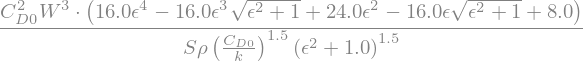

In [12]:
display(simplify(expand(Pr_3**2)))
# print(Pr_3**2)
# print("$$%s$$"%latex(Pr_3**2))


$$\frac{2~W^{3}~\left(C_{D_0} + k~\left(-\epsilon~\sqrt{\frac{C_{D_0}}{k}} + \sqrt{\frac{C_{D_0}}{k}} ~\sqrt{\epsilon^{2} + 1}\right)^{2}\right)^{2}}{\rho~S~\left(\frac{C_{D_0}}{k}\right)^{1.5}~\left(\epsilon^2 + 1\right)^{1.5}}$$

$$Pr_3^2 = \dfrac{2~W^{3}}{S~\rho}~C_{D_0}^2\frac{ \left(1+  \left(- \epsilon  +   \sqrt{\left(\epsilon^2 + 1\right)}\right)^{2}\right)^{2}}
{\left(\frac{C_{D_0}}{k}\right)^{3/2}~\left(\epsilon^2 + 1\right)^{3/2}}$$

 


<div class="alert alert-block alert-success">
$$
\begin{eqnarray}
Pr_3 &=& D_3 \times  V_2 = q_3~S~C_{D_3}~V_3 =  \dfrac{W}{C_{L_3}}~C_{D_3}~\sqrt{\dfrac{2~W}{\rho~S~C_{L_3}}}
=\dfrac{W}{C_{L_3}}~2~k~C_{L_3}~(C_{L_3} - C_{L_0})~\sqrt{\dfrac{2~W}{\rho~S~C_{L_3}}} \\
 &=&  k~(C_{L_3} - C_{L_0})~\sqrt{\dfrac{8~W^3}{\rho~S~C_{L_3}}}  =  \dfrac{C_{D_0}} {C_{L_3} + C_{L_0}}  \sqrt{\dfrac{8W^3}{\rho S C_{L_3}}}
\end{eqnarray}$$
</div>


On peut aussi calculer une correction sur la puissance requise en effectuant le calcul
$Pr_3 / Pr_1 $ avec

<div class="alert alert-block alert-info">
<b>Puissance de référence </b>
$$
Pr_1 =  \sqrt{\dfrac{8~W^3}{\rho~S}}~k~\left(C_{D_0} / k\right)^{\frac 1 4} = 
\sqrt{\dfrac{8~W^3}{\rho~S}}~k~\sqrt{C_{L_{ref}}} =  
k~C_{L_{ref}}~\sqrt{\dfrac{8~W^3}{\rho~S~C_{L_{ref}}}}  
$$
</div>

On a alors:

<div class="alert alert-block alert-danger">
<b> Correction sur la puissance requise</b>
    
$$
\dfrac{Pr_3}{Pr_1 } = \dfrac{C_{L_3} - C_{L_0}}{C_{L_{ref}}}~\sqrt{\dfrac{C_{L_{ref}}}{C_{L_3}}}
= \dfrac{\sqrt{1 +\epsilon^2} - \epsilon}{(1 +\epsilon^2)^{1/4}}
$$
</div>

### Graphique des corrections

On prend en compte 4 corrections:

1. sur le coefficient de portance
2. sur le coefficient de traînée
3. sur la finesse
4. sur la vitesse optimale

In [13]:
def drag_correction(x):
    y = np.sqrt(1 + x**2)
    return y * (y - x)
def lift_correction(x):
    return np.sqrt(1 + x**2)
def f_correction(x):
    return 1 / (np.sqrt(1+x**2)-x)
def speed_correction(x):
    return pow(1 + x**2, -1/4)
def power_correction(x):
    return  speed_correction(x) / f_correction(x)
 

## Application numérique
###  **<span style="color:magenta"> Calcul de la finesse optimale, des $C_L$, $C_D$ et $D$ correspondant </span>**

     
$\rho = 1.1$ kg/m$^3$,  $C_{D_0} = 0.013$, $C_{L_0} = 0.05$, $e=0.85$, $\lambda=5$, $S=30$ m$^2$, $W = 5000 \times g$ N 

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

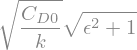

In [14]:
value = {rho: 1.1, C_D0: 0.013, C_L0: 0.05, e: 0.85, lambda_: 5, S:30, V:350/3.6, W: 5000 * 9.81}
epsilon_num = value[C_L0] / np.sqrt(value[C_D0] * np.pi * value[e] * value[lambda_] )
value[epsilon]  = epsilon_num
print_("\epsilon", epsilon_num)
print_("\sqrt{1+\epsilon^2}",np.sqrt(1 + epsilon_num**2))
k_num = lambdify((lambda_, e), k_value, "numpy")
value[k] = k_num(value[lambda_], value[e])
print_("k", k_value)
print_("k", value[k])
display(C_L_3)

In [15]:
C_L_3_num = lambdify((k, C_D0, epsilon), C_L_3, "numpy")
print_("C_{L_3}", C_L_3)
print_("C_{L_3}", C_L_3_num(value[k], value[C_D0], epsilon_num))
CL3_num = C_L_3.subs(value).evalf()
print_("C_{L_3}", CL3_num)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [16]:
CD3_num = C_D_3.subs(value).evalf()
print_("C_{D_3}", CD3_num)
f_3 = f_max.subs(value).evalf()
print_("f_{\\max}", f_3)
print_("f_{\\max} (ref)", 1 / 2 * np.sqrt(np.pi * value[lambda_] * value[e] / value[C_D0]))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [17]:
V_3_num = V_3.subs(value).evalf()*3.6
print_("V_3 [km/h]", V_3_num)

<IPython.core.display.Latex object>

In [18]:
Pr3_num = Pr_3.subs(value).evalf()
print_("Pr_3 [kW]", Pr3_num / 1000)
 

<IPython.core.display.Latex object>

In [19]:
Pr_1 = sqrt(8 * W**3/(rho * S)) * k * (C_D0/k)**0.25
print_("Pr_1", Pr_1)
Pr1_num = Pr_1.subs(value).evalf()
print_("Pr_1 [kW]",  Pr1_num/1000)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<hr style="border:2px solid orange " width="99%">

# **<span style="color:red">II - Optimisation de la puissance requise</span>**

<hr style="border:2px solid orange " width="99%">

Le travail est très similaire

D'abord on écrit la puissance requise sous la forme:

<div class="alert alert-block alert-success">
<b>Loi de puissance requise  $Pr$</b>
$$
Pr(V)=  \dfrac 1 2~\rho~S~C_D~V^3 = a_1~V^3 + \dfrac{a_2}{V} + a_3~V
$$ 
</div>

## Méthode

1. Calculer $V_4$ telle que $\dfrac{dPr}{dV} = 0$
2. En déduire toutes les autres quantités $Pr_4$, $C_{L_4}$, $C_{D_4}$, $f_4$, $D_4$

In [20]:
# déclaration des variables additionnelles
a_1, a_2, a_3, Pr_ = symbols("a_1, a_2, a_3, Pr_")

### Loi de puissance

In [21]:
q = 1/2 * rho * V**2
C_L = W / (q * S)
C_D = C_D0 + k * (C_L-C_L0)**2
D = q * S * C_D
L = q * S * C_L
Pr = D * V
Pr_tmp = expand(Pr.simplify())
print_("Pr", collect(Pr_tmp, V))

<IPython.core.display.Latex object>

**Extraire les coefficients $a_1$, $a_2$, $a_3$**

In [22]:
V3, CL3,fmax = symbols("V3, CL3, fmax")
a1 = Pr_tmp.coeff(V, 3)
#a1 = W/V3**2
a2 = Pr_tmp.coeff(V, -1)
# a2 = k*W**2/2 * CL3/a1
a3 = Pr_tmp.coeff(V, 1)
#a3 = W * (1/fmax - 2 * k  *CL3) 
print_("a_1", a1)
print_("a_2", a2)
print_("a_3", a3)
print_("\\frac{a_2}{a_1}", a2/a1)
print_("\\dfrac{a_3}{a_1}", a3/a1)
print_("12a_1a_2 + a_3^2", expand(12*a1*a2+a3**2))
print_("a_1a_2", simplify(a1*a2))



<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [23]:
print_("\\dfrac{4 a_1a_2}{a_3^2}", expand(4 * a1*a2/a3**2))
print_("\\dfrac{a_3^2}{a_1^2}", a3**2/a1**2)
print_("\\dfrac{C_{L_0}^2}{C_{L_3}^2}",expand(C_L0**2/C_L_3**2))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<div class="alert alert-block alert-success">
<b>Coefficients de la loi de puissance requise  $Pr$</b>
$$
a_1 = \dfrac{\rho~S}{2}~(C_{D_0}+ k~C_{L_0}^2) = \dfrac{\rho~S~C_{D_0}}{2}~(1 +\epsilon^2), \qquad \qquad 
a_2 = \dfrac{2~W^2~k}{\rho~S},\qquad \qquad
a_3 = - 2~W~k~C_{L_0} = - 2~W~\sqrt{k C_{D_0}}~\epsilon
$$ 
</div>

Avec

<div class="alert alert-block alert-info">
<b>Relations utiles avec $Pr$</b>
$$
\dfrac{C_{L_0}^2}{C_{L_3}^2} = \dfrac{\epsilon^2}{1+\epsilon^2}
$$
    
et

$$
\dfrac{a_2}{a_1}= \left(\dfrac{2~W}{\rho~S~C_{L_0}}\right)^2 \dfrac{1}{1+\epsilon^2}=
\left(\dfrac{2~W}{\rho~S~C_{L_3}}\right)^2, \qquad
\dfrac{a_3}{a_1} = - \dfrac{4~W}{\rho~S~C_{L_0}~(1+\epsilon^2)} =
-~\dfrac{4~W}{\rho~S~C_{L_3}}~\dfrac{C_{L_0}}{C_{L_3}}, 
\qquad\dfrac{4~a_1~a_2}{a_3^2}=1 +  \dfrac{C_{D_0}}{k~C_{L_0}^2} = 1 + \epsilon^2
$$    

$$
12~a_1~a_2 + a_3^2 = 4~W^2~k~C_{D_0}~(4~\epsilon^2 + 3)
$$
   
</div>


### Calcul de la vitesse optimale $V_4$

In [24]:
def solve_min_Pr(P, V):
    sol = solve(P.diff(V), V)
    print_("Solution", sol)
    return sol
Pr_ = a_1 * V**3 + a_2 / V + a_3 * V
sol1 = solve_min_Pr(Pr_, V)
sol2 = solve_min_Pr(Pr_tmp, V)
V_4a = sol1[3]   # attention il faut vérifier, ce n'est pas toujours le même index
V_4b = sol2[3]   # attention il faut vérifier, ce n'est pas toujours le même index


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Vitesse au carré

In [22]:
print_("V_{4_a}^2", V_4a**2)
print_("V_{4_b}^2",  V_4b**2)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>


$$
V_4^2 = \dfrac{ \sqrt{12 a_1 a_2 + a_3^2} - a_3}{6 a_1}
$$


<div class="alert alert-block alert-success">
<b>Vitesse optimale $V_4$</b>
$$
V_4^2 =V_{ref}^2~\dfrac{1}{3}~\dfrac{\epsilon + \sqrt{4~\epsilon^2+3}}{1 + \epsilon^2},  \qquad \qquad 
V_3^2 =V_{ref}^2~\dfrac{1}{\sqrt{1 + \epsilon^2}},\qquad \qquad 
V_4^2 =V_{3}^2~\dfrac{\epsilon + \sqrt{4~\epsilon^2+3}}{3\sqrt{1 + \epsilon^2}}
$$
    
    
$$
V_4^2 = \dfrac{1}{6}~\left(\sqrt{12~\dfrac{a_2}{a_1} + \left(\dfrac{a_3}{a_1}\right)^2} -\dfrac{a_3}{a_1} \right)
=
 \dfrac{1}{3}~\left(\sqrt{\dfrac{3~a_2}{ a_1} + \left(\dfrac{a_3}{2~a_1}\right)^2} -\dfrac{a_3}{2~a_1} \right)
%= \dfrac{1}{3} \dfrac{2 W}{\rho S C_{L_3}} \left[  \sqrt{3 + \left(\dfrac{C_{L_0}}{C_{L_3}} \right)^2}  +\epsilon \right]
%= \dfrac{V_3^2}{3}\sqrt{3 + \left(\dfrac{C_{L_0}}{C_{L_3}} \right)^2}
$$
</div>


avec $V_3^2 = \sqrt{\dfrac{a_2}{a_1}} $


De la relation 

$$
V_4^2 = \dfrac{V_3^2}{3} \dfrac{\epsilon + \sqrt{4~\epsilon^2+3}}{3~\sqrt{1 + \epsilon^2}}
$$
 
on trouve que 
$$ \dfrac{1}{3} \leqslant  \dfrac{V_4^4 }{V_3^4}\leqslant 1$$
 

In [25]:
def velocity_factor(eps):
    """ (V_4/V_3)^2"""
    return (eps + np.sqrt(4 * eps**2 + 3)) / ( 3 * np.sqrt(1 + eps**2))


### Vitesse à la puissance 4

Pour voir s'il y a des simplifications

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

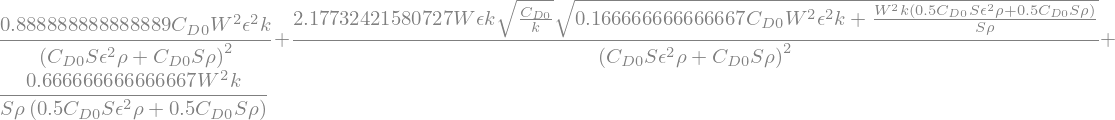

In [26]:
print_("V_{4_a}^4", expand(V_4a**4))
print_("V_{4_b}^4", expand(V_4b**4))
V4c4=expand(V_4a**4)
display(V4c4.subs({a_1:a1,a_2:a2,a_3:a3} ))


$$
V_4^2 = \dfrac{\sqrt{12~a_1~a_2 + a_3^2} - a_3}{6~a_1}
$$


La vitesse optimale vérifie:

<div class="alert alert-block alert-success">
<b>Vitesse optimale $V_4$</b>
$$
V_4^4 = \dfrac{1}{3}~\dfrac{a_2}{a_1} + \dfrac{a_3^2 - a_3~\sqrt{12~a_1~a_2 - a_3^2} }{18~a_1^2} 
 =  V_3^4 \left(\dfrac{1}{3}~\bigl(1 + g(\epsilon)\bigr)\right)
=  \dfrac{1}{3}~V_3^4 \left[
1 + \dfrac{a_3^2}{6~a_2~a_1}~\left(1 - \sqrt{1+ 12~\dfrac{a_1~a_2}{a_3^2}} \right) \right]
$$
     
On retrouve le facteur entre 1/3 entre les vitesses à la puissance 4 !


### Calcul de $C_{L_4}$ et  $C_{D_4}$

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

'f_4'

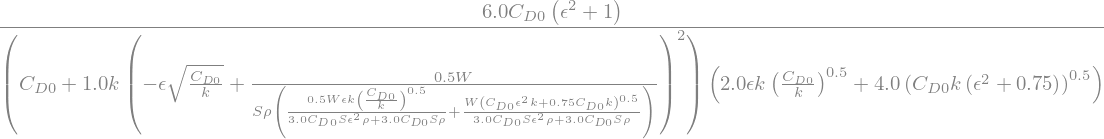

In [27]:
C_L_4 = simplify(W / (q.subs(V, V_4a) * S))
print_("C_{L_4} = f(a_1, a_2, a_3)", C_L_4)
C_L_4_value = simplify( W / (q.subs(V, V_4b) * S))
print_("C_{L_4} value", C_L_4_value)
C_D_4_value = C_D.subs(V, V_4b)
print_("C{D_4} value", C_D_4_value)
C_D_4 = C_D.subs({C_L:C_L_4, V: V_4a})
print_("C_{D_4}", C_D_4)
f_4_value = C_L_4_value / C_D_4_value
display("f_4",f_4_value)

----

$$
C_{L_4} = \dfrac{W}{\rho~S}~\dfrac{12~a_1}{-a_3 + \sqrt{a_3^2 + 12~a_1~a_2}}
$$

 

<div class="alert alert-block alert-success">
<b> $C_{L_4}$</b>
 $$
C_{L_4} =  \dfrac{3~(C_{D_0} + k~C_{L_0}^2)}{k~C_{L_0} + 2~\sqrt{k~(\dfrac{3}{4}~C_{D_0}+ k~C_{L_0}^2)}}
=  C_{L_{ref}}~\dfrac{3~(1 + \epsilon^2)}{\epsilon + \sqrt{4~\epsilon^2 + 3}}
$$
</div>


et on peut en extraire $C_{L_4}/C_{L_3}$ en fonction de $\epsilon$.

Mais plus astucieux, partons de l'équation de la portance:

$$ W = \dfrac{1}{2}~\rho~S~C_{L_3}~V_3^2 =
\dfrac{1}{2}~\rho~S~C_{L_4}~V_4^2 
$$
 
On obtient alors

<div class="alert alert-block alert-info">
<b> Rapport $\dfrac{C_{L_4}}{C_{L_3}}$</b>
$$\dfrac{C_{L_4}}{C_{L_3}} =  \dfrac{V_3^2}{V_4^2} = \sqrt 3 ~\sqrt{\dfrac{1+\epsilon^2}{1+4~\epsilon^2/3}}
$$
</div>


donc
$$
C_{D_4} =  C_{D_0} + k~\left(C_{L_4} - C_{L_0} \right)^2
$$
</div>

 
 La finesse est donnée par:
 
 $$
 f_4  =  \dfrac{C_{L_4}}{C_{D_4}} 
 $$

 Il n'est pas judicieux de faire plus de développement sur le $C_{D_4}$ et la finesse à ce niveau
 en cherchant analytiquement 
 $$
 \dfrac{C_{L_4}}{C_{L_3}}, \qquad \qquad \dfrac{f_4}{f_3}
 $$

Mais c'est fait plus loin, avec la puissance
 

### Calcul de $Pr_\min$

In [29]:
Pr_min=simplify(Pr_.subs(V, V_4a))
print_("Pr_{\min}", Pr_min)
Pr_min_b = simplify(Pr.subs(V, V_4b))

print_("Pr_{\min} (value)", Pr_min_b)
 

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

$$ Pr_4 = D_4 V_4 =  \dfrac{1}{2} \rho S C_{D_4} V_4^3$$

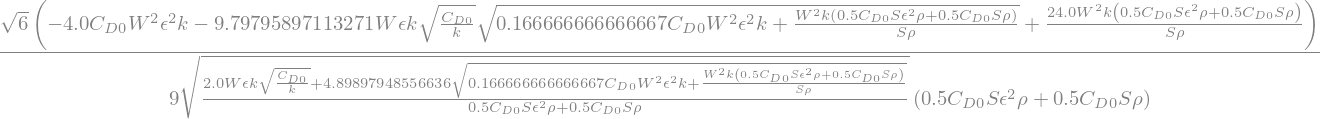

In [30]:
A = Pr_min.subs({a_1:a1,a_2:a2,a_3:a3} )
 
display(A)

Une forme plus simple de la puissance requise s'écrit alors  par:
<div class="alert alert-block alert-info">
<b> Puissance requise minimale</b>
$$
Pr_4 = \dfrac{\sqrt 6}{9\sqrt a_1} ~ \dfrac{12~a_1~a_2 + a_3~\left(\sqrt{12~a_1~a_2+a_3^2} - a_3\right)}
{\sqrt{\sqrt{12~a_1~a_2+a_3^2} - a_3}}
$$
</div>
 
 

On peut pousser plus loin les développements analytiques, mais ce n'est pas nécessaire.

$$
V_4 = V_{ref}~\left(\dfrac{1}{3}~\dfrac{\epsilon + \sqrt{4~\epsilon^2+3}~}{1 + \epsilon^2}\right)^{1/2}, \qquad \qquad
C_{L_4} =  C_{L_{ref}}~\dfrac{3~(1 + \epsilon^2)}{\epsilon + \sqrt{4~\epsilon^2 + 3}}
$$

$$
Pr_4 = \dfrac{\rho~S}{2}~C_{D_4}~V_4^3 = 
\dfrac{\rho~S}{2}~C_{D_0}~\left[ 1 +  \left(\dfrac{C_{L_4}}{C_{L_{ref}}} - \epsilon\right)^2 \right]
V_4^3 
$$

 
<div class="alert alert-block alert-success">
 
$$
Pr_4 = \dfrac{\rho~S}{2}~C_{D_0}~V_{ref}^3~\left[
1 +  \left(\dfrac{3~(1 + \epsilon^2)}{\epsilon + \sqrt{4~\epsilon^2 + 3}}  - \epsilon\right)^2 \right]
\times  \left(\dfrac{1}{3}~\dfrac{\epsilon + \sqrt{4~\epsilon^2+3}}{1 + \epsilon^2}\right)^{3/2}
$$ 
</div> 

In [31]:
r = 3 * (1 + epsilon**2) /(epsilon + sqrt(4*epsilon**2 +3))
x = 3 * (1 + epsilon**2) - epsilon * (epsilon + sqrt(4*epsilon**2 +3))
display(expand(x))
display(expand(x**2))
display(expand(x**2 +(epsilon + sqrt(4*epsilon**2 +3))**2 ))

$$
Pr_4 =  \dfrac{\rho~S}{2}~C_{D_0}~V_{ref}^3~\left[
1+\left(\dfrac{3~(1 + \epsilon^2)}{\epsilon + \sqrt{4~\epsilon^2+3}} - \epsilon\right)^2 \right]
  = 
 \dfrac{4}{3^{3/2}}~\dfrac{\rho~S}{2}~C_{D_0}~V_{ref}^3~  
 \dfrac{3-  \epsilon~(1+\epsilon^2)~\sqrt{4~\epsilon^2+3} + 5~\epsilon^2 + 2~\epsilon^4} 
 {
 \left(1 + \epsilon^2\right)^{3/2}~\sqrt{\epsilon + \sqrt{4~\epsilon^2+3} }}
$$

<div class="alert alert-block alert-success">
 
$$
Pr_4 =Pr_1 \times \dfrac{2}{3^{3/2}}   
 \dfrac{3-\epsilon~(1+\epsilon^2)~\sqrt{4~\epsilon^2+3} + 5~\epsilon^2 + 2~\epsilon^4} 
 {
 \left(1 + \epsilon^2\right)^{3/2}~\sqrt{\epsilon + \sqrt{4~\epsilon^2+3} }}
$$
     
</div>

## Application numérique
###  **<span style="color:magenta"> Calculer le $C_L$, $C_D$, $D$ et $Pr$ correspondant </span>**


In [32]:
V_4_num =  V_4b.subs(value).evalf()*3.6
print_("V_4 [km/h]", V_4_num)
print_("\\frac{V_4}{V_3}", V_4_num/V_3_num)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [33]:
CL_4_num = C_L_4_value.subs(value).evalf()
print_("C_{L_4}", CL_4_num)
print_("\\frac{C_{L_4}}{C_{L_3}}", CL_4_num / CL3_num)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [34]:
CD_4_num = C_D_4_value.subs(value).evalf()
print_("C_{D_4}", CD_4_num)  
f_4_num = CL_4_num / CD_4_num
print_("f_4", f_4_num)
print_("\\frac{f_4}{f_3}", f_4_num / f_3)
print_("\\frac{C_{D_4}}{C_{D_3}}", CD_4_num /  CD3_num)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [35]:
print_("a_1", a1.subs(value))
print_("a_2 \\times 10^{-6}", a2.subs(value)/1e6)
print_("a_3", a3.subs(value))
Pr_min_num = Pr_min_b.subs(value).evalf()
print_("Pr_{\\min} [kW]", Pr_min_num/1000)
print_("\\frac {Pr_4}{Pr_3}", Pr_min_num/Pr3_num)
print_("\\frac {Pr_4}{Pr_1}", Pr_min_num/Pr1_num)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [36]:
eps = 0.120013175404869

def V4_V3(eps):
    x = (eps + np.sqrt(4 * eps**2 + 3)) / np.sqrt(1 + eps**2)
    return np.sqrt(1/3 * x)

def Pr4_Pr1(eps):
    a = 1 + eps**2
    b = np.sqrt(3 + 4 * eps**2 )
    c = np.sqrt(eps + b)
    denom = a**1.5 * c
    num = 3 - eps * a * b + 5 * eps**2 + 2 * eps**4 
    return num / denom * 2 / pow(3, 1.5)

def Pr3_Pr1(eps):
    a = 1 + eps**2
    return (np.sqrt(a)-eps) / pow(a, 1/4)

print_("V_4/V_3", V4_V3(eps))

print_("Pr_4/Pr_1", Pr4_Pr1(eps))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

 <hr style="border:2px solid orange " width="99%">
 
 # **<span style="color:red">III - Conclusions </span>**

<hr style="border:2px solid orange " width="99%">

1. On a des paramètres d'entrées:

$$
\rho, S, W, C_{L_0},  C_{D_0}, e, \lambda
$$

2. On a les données de sorties:

$$
C_{L_3},  C_{D_3}, f_3, V_3, Pr_3, C_{L_4},  C_{D_4}, f_4, V_4, Pr_4
$$


et on a les liens complexes entre les entrées et les sorties, qu'on vient de déterminer.

**Comment utiliser tout cela maintenant ?**

On peut faire du pré-design ou pré-conception:

* Les formules analytiques permettent de mettre en valeur les dépendances des différents paramètres sur les vitesses, forces et puissances en fonction des différents critères.

* avec les dépendances connues on peut effectuer:
    * de la conception directe : on se fixe les paramètres on trouve les sorties (vitesses, forces, puissances)
    * de la conception inverse: on se fixe les sorties (vitesses, forces, puissances) et on trouve les bons paramètres.
    
* les approches inverses sont toujours plus difficiles à mener que les approches directes car les problèmes sont très souvent fortement non linéaires.



# **<span style="color:red">III - Approche "Design"</span>**

## **<span style="color:blue">III-1) Approches conceptions</span>**

1. Conception directe:

    * Entrées:
    $$
    h, W, S  \lambda, e, C_{D_0}, C_{L_0}
    $$

    * Sorties:
    $$
    W/S, \epsilon, S, b, \rho, k , C_{L_i}, C_{D_i}, f_i, V_i, D_i, Pr_i 
    $$
    
    * indice 1: finesse maximale i.e. indice 3 dans ce fichier
    * indice 2: puissance minimale, i.e indice 4 dans ce fichier

2. Conception inverse:

    * Entrées:
    $$
    e, h, C_{L_3}, f_3, V_3, Pr_3, \epsilon 
    $$
    
    * Sorties:
    $$
    \rho, k,  C_{L_0}, C_{D_0}, \lambda, S, b,   W, W/S,  C_{L_2}, f_2, V_2, Pr_2 
    $$
    
## **<span style="color:blue">III-2) Conception directe</span>**

C'est l'approche employée jusqu'à maintenant, à partir de quelques paramètres avions et de ceux de la polaire
on calcule les quantités inconnues via les relations trouvées précédemment.



## **<span style="color:blue">III-3) Conception inverse</span>**
 

### 0- Masse volumique et pression dynamique

l'altitude $h$ permet d'avoir la masse volumique $\rho = \sigma(h)~\rho_0$

$$
q_3 = \dfrac{1}{2}~\rho~V^3_3
$$

### 1- Calcul du poids

$$
Pr_3 = D~V_3 = \dfrac{W}{f_\max}~V_3 \qquad \Longrightarrow \qquad  W = \dfrac{Pr_3~f_\max}{V_3}
$$


$$
\dfrac{W}{S} = q_3~C_{L_3}, \qquad \textrm{et} \qquad S  = \dfrac{W}{q_3~C_{L_3}} 
$$

### 3 - Calcul du $C_{D_3}$

$$
f_3 = \dfrac{C_{L_3}}{C_{D_3}} \qquad \Longrightarrow \qquad  C_{D_3} = \dfrac{C_{L_3}}{f_3}
$$

###  4 - Calcul des coefficients de la polaire

1. On part du coefficient de traînée 
$$
C_{D_3} = C_{D_0} + k~(C_{L_3} - C_{L_0})^2 =  2~C_{D_0}~\sqrt{1 +\epsilon^2}~\left(
\sqrt{1 +\epsilon^2} - \epsilon \right)
\qquad \textrm{ou} \qquad C_{D_0} = \dfrac{C_{D_3}}{2~\sqrt{1 +\epsilon^2} }
$$


2. On prend le calcul du coefficient de portance:
 
$$C_{L_3}^2 = \dfrac{C_{D_0}}{k}~(1 +\epsilon^2)  \qquad \Longrightarrow \qquad
k = \dfrac{(1 +\epsilon^2)~C_{D_0}}{C_{L_3}^2}$$

3. on prend la définition de $\epsilon$

$$\epsilon^2 = \dfrac{k~C_{L_0}^2}{C_{D_0}} \qquad \Longrightarrow \qquad 
C_{L_0} = \epsilon~\sqrt{\dfrac{C_{D_0}}{k}}
$$
ou
$$
\dfrac{C_{L_0}^2}{C_{L_3}^2} = \dfrac{\epsilon^2}{1+\epsilon^2} \qquad \Longrightarrow \qquad  
C_{L_0} = \dfrac{\epsilon~C_{L_3}}{\sqrt{1+\epsilon^2}}   
$$ 

a priori les quantités $C_{L_3}$ et $C_{L_0}$ sont positives

### 5 - Les autres quantités

Avec ce premier jeu de paramètres calculés, on retrouve les autres quantités inconnues, par les relations données dans l'approche directe.

## **<span style="color:blue">III-4) Conception inverse</span>**

Pour les avions à hélice on connaît mieux $Pr_4^{ref}$ que $Pr_3$, par contre on suppose qu'on connaît toujours
$C_{L_3}$, $f_{\max}$ et $V_3$.

Peut-on résoudre facilement le problème inverse ?

Proposer une idée.

**Réponse**

Le problème devient trop complexe à cause de $\epsilon$ qui intervient de façon extrêmement complexe dans les relations.

Il faut donc démarrer avec une valeur de $\epsilon$ faire les calculs comme précédemment pour calculer   $Pr_4(\epsilon)$
puis modifier $\epsilon$ pour arriver à la puissance imposée initiale $Pr_4^{ref}$